In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataevaluator import DataEvaluator
from helper import evaluate_model, train_model
from models.knn import KNN
from models.mlp import MLP
from models.logistic import LogReg
from models.cnn import CNN

In [6]:
data = DataEvaluator('dataset')
X_train, y_train, X_val, y_val, X_test, y_test = data.get_data()
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)
clothing_types = data.clothing_types

(51000, 784) (51000,) (9000, 784) (9000,) (10000, 784) (10000,)


In [7]:
# CNN data preprocessing

X_train_cnn = X_train.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_val_cnn   = X_val.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_test_cnn  = X_test.reshape((-1, 28, 28, 1)).astype("float32") / 255.0

print(X_train_cnn.shape)
print(X_val_cnn.shape)
print(X_test_cnn.shape)

X_train_cnn = X_train_cnn.astype("float32") / 255.0
X_val_cnn   = X_val_cnn.astype("float32") / 255.0
X_test_cnn  = X_test_cnn.astype("float32") / 255.0

(51000, 28, 28, 1)
(9000, 28, 28, 1)
(10000, 28, 28, 1)


## Data Exploration

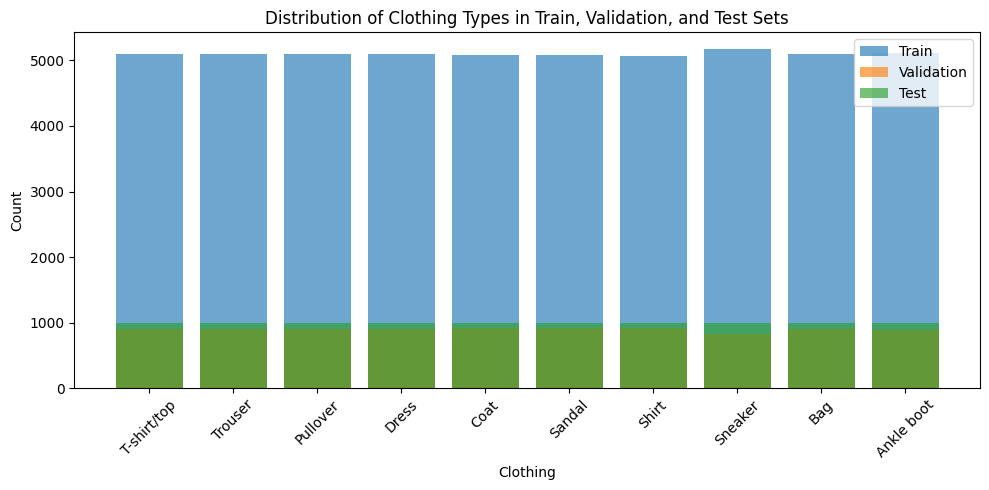

In [8]:
data.plot_clothing_distribution()
print()

# Model Initialization Logic Here

In [9]:
l = LogReg()
k = KNN()
f = MLP()
c = CNN()

c:\Users\Oboes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Training Models

In [10]:
ltime = train_model(l, "Logistic Regression", X_train, y_train)
print(f"Training time for Logistic Regression: {ltime:.2f} seconds")

Training time for Logistic Regression: 136.50 seconds


c:\Users\Oboes\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
kfit_time = train_model(k, "kNN", X_train, y_train)
print(f"Training time for kNN: {kfit_time:.2f} seconds")

Training time for kNN: 0.01 seconds


Training time for MLP: 539.72 seconds


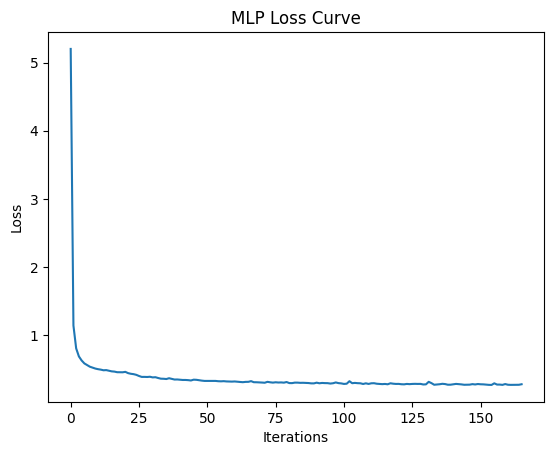

In [12]:
ftime = train_model(f, "MLP", X_train, y_train)
print(f"Training time for MLP: {ftime:.2f} seconds")

plt.plot(f.classifier.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Loss Curve')
plt.savefig('figures/MLP_loss_curve.png')
plt.show()

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5386 - loss: 1.2490 - val_accuracy: 0.7204 - val_loss: 0.7737
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7029 - loss: 0.7989 - val_accuracy: 0.7302 - val_loss: 0.7008
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.7240 - loss: 0.7365 - val_accuracy: 0.7547 - val_loss: 0.6476
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7380 - loss: 0.6939 - val_accuracy: 0.7667 - val_loss: 0.6150
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7500 - loss: 0.6639 - val_accuracy: 0.7769 - val_loss: 0.5777
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.7621 - loss: 0.6296 - val_accuracy: 0.7886 - val_loss: 0.5570
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.7722 - loss: 0.6081 - val_accuracy: 0.7957 - val_loss: 0.5387
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7809 - loss: 0.5874 - v

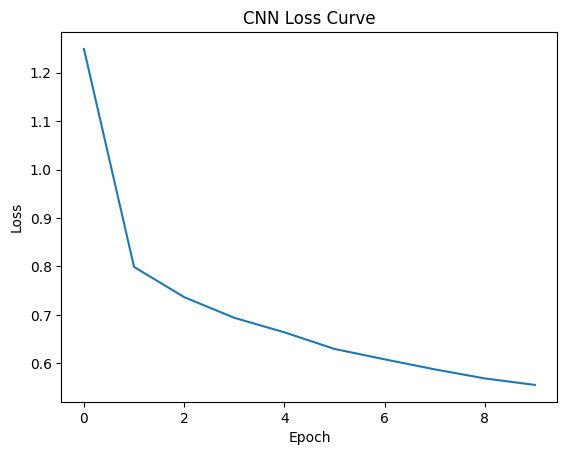

In [13]:
ctime = train_model(c, "CNN", X_train_cnn, y_train)
print(f"Training time for CNN: {ctime:.2f} seconds")

plt.plot(c.history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Curve")
plt.show()

Logistic Regression Accuracy: 0.8352222222222222  Precision: 0.8340474861761206  Recall: 0.8352222222222222  F1 Score: 0.8341134022212633


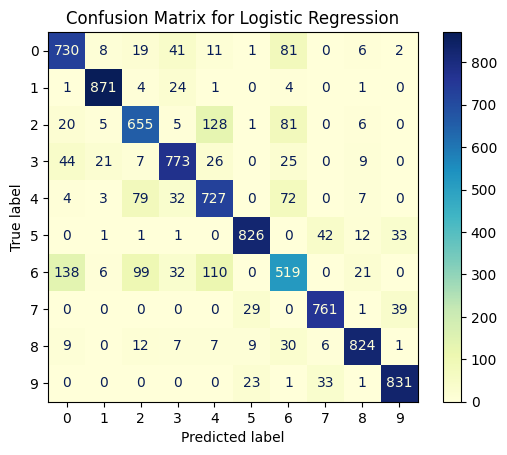

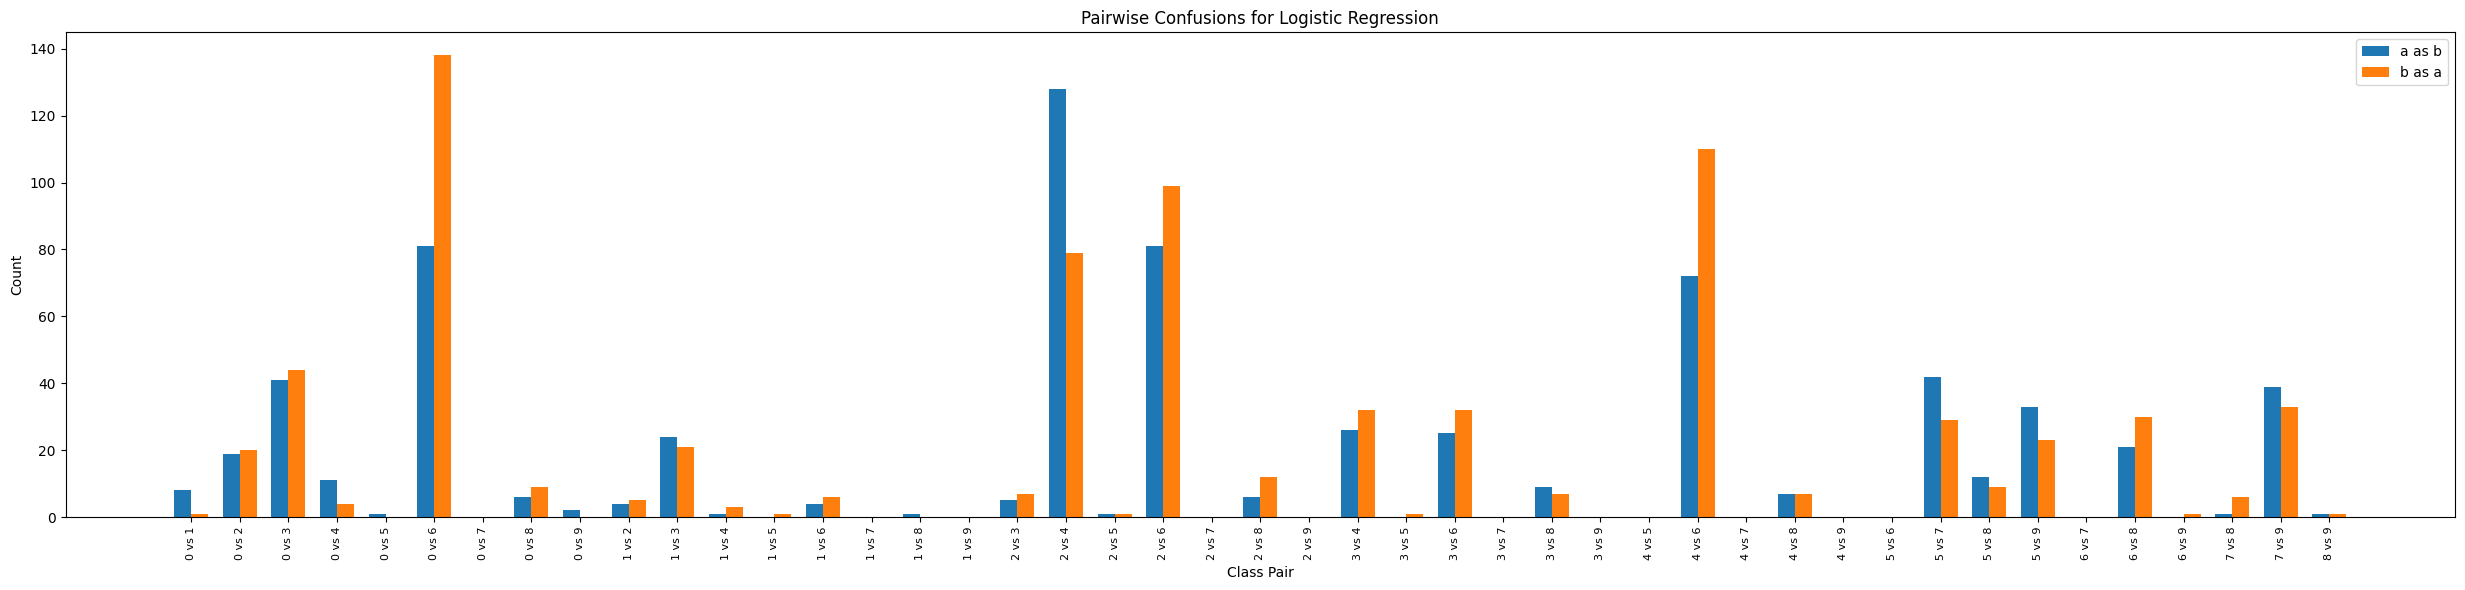

Logistic Regression class 0 AUC: 0.9802065112602998
Logistic Regression class 1 AUC: 0.9976974468319542
Logistic Regression class 2 AUC: 0.9698207490298676
Logistic Regression class 3 AUC: 0.9887269612577165
Logistic Regression class 4 AUC: 0.9731504977604531
Logistic Regression class 5 AUC: 0.9957397382073383
Logistic Regression class 6 AUC: 0.932103957827797
Logistic Regression class 7 AUC: 0.996033091976228
Logistic Regression class 8 AUC: 0.9894539634656138
Logistic Regression class 9 AUC: 0.996366222931294


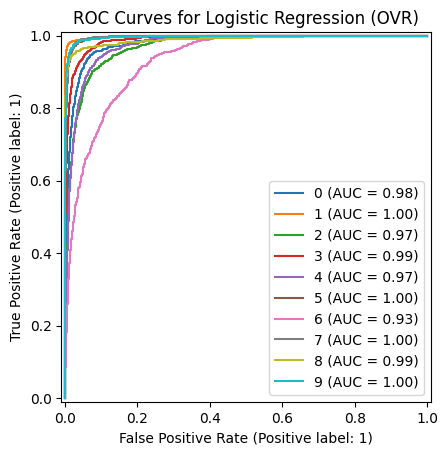

Logistic Regression pair 0 vs 7 AUC: 0.9999772169880858
Logistic Regression pair 1 vs 7 AUC: 0.99998404212878
Logistic Regression pair 1 vs 9 AUC: 0.9999192981671993


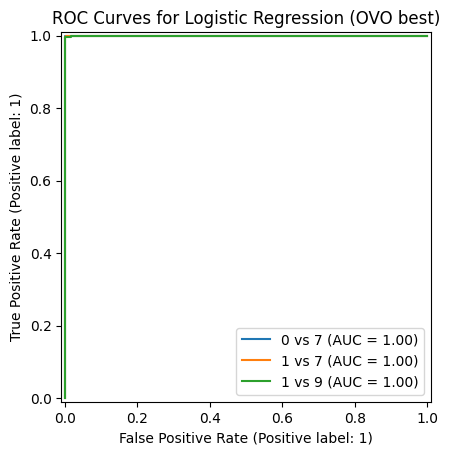

Logistic Regression pair 0 vs 6 AUC: 0.8304602711721732
Logistic Regression pair 2 vs 4 AUC: 0.8996497398273203
Logistic Regression pair 4 vs 6 AUC: 0.8447654147654148
Logistic Regression pair 2 vs 6 AUC: 0.824020157782644
Logistic Regression pair 0 vs 3 AUC: 0.9703365925306818


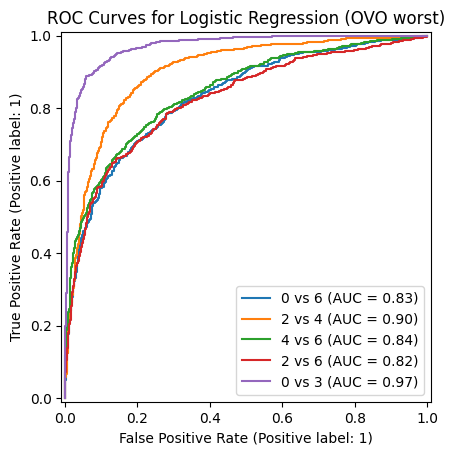

Validation time for Logistic Regression: 1.55 seconds


In [14]:
le, levals, letime = evaluate_model(l, "Logistic Regression", X_val, y_val, stage="validation", color="YlGnBu")
print(f"Validation time for Logistic Regression: {letime:.2f} seconds")

kNN Accuracy: 0.8485555555555555  Precision: 0.8518505535144103  Recall: 0.8485555555555555  F1 Score: 0.8476630797526208


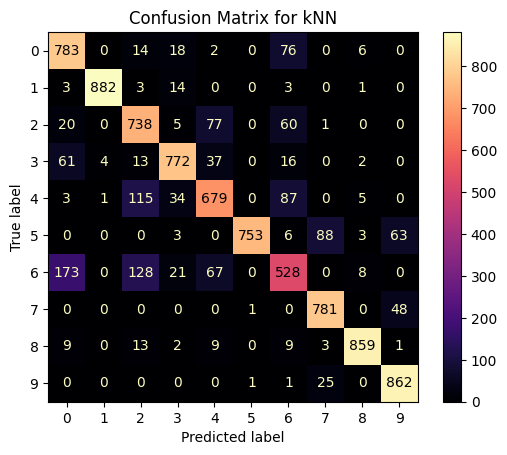

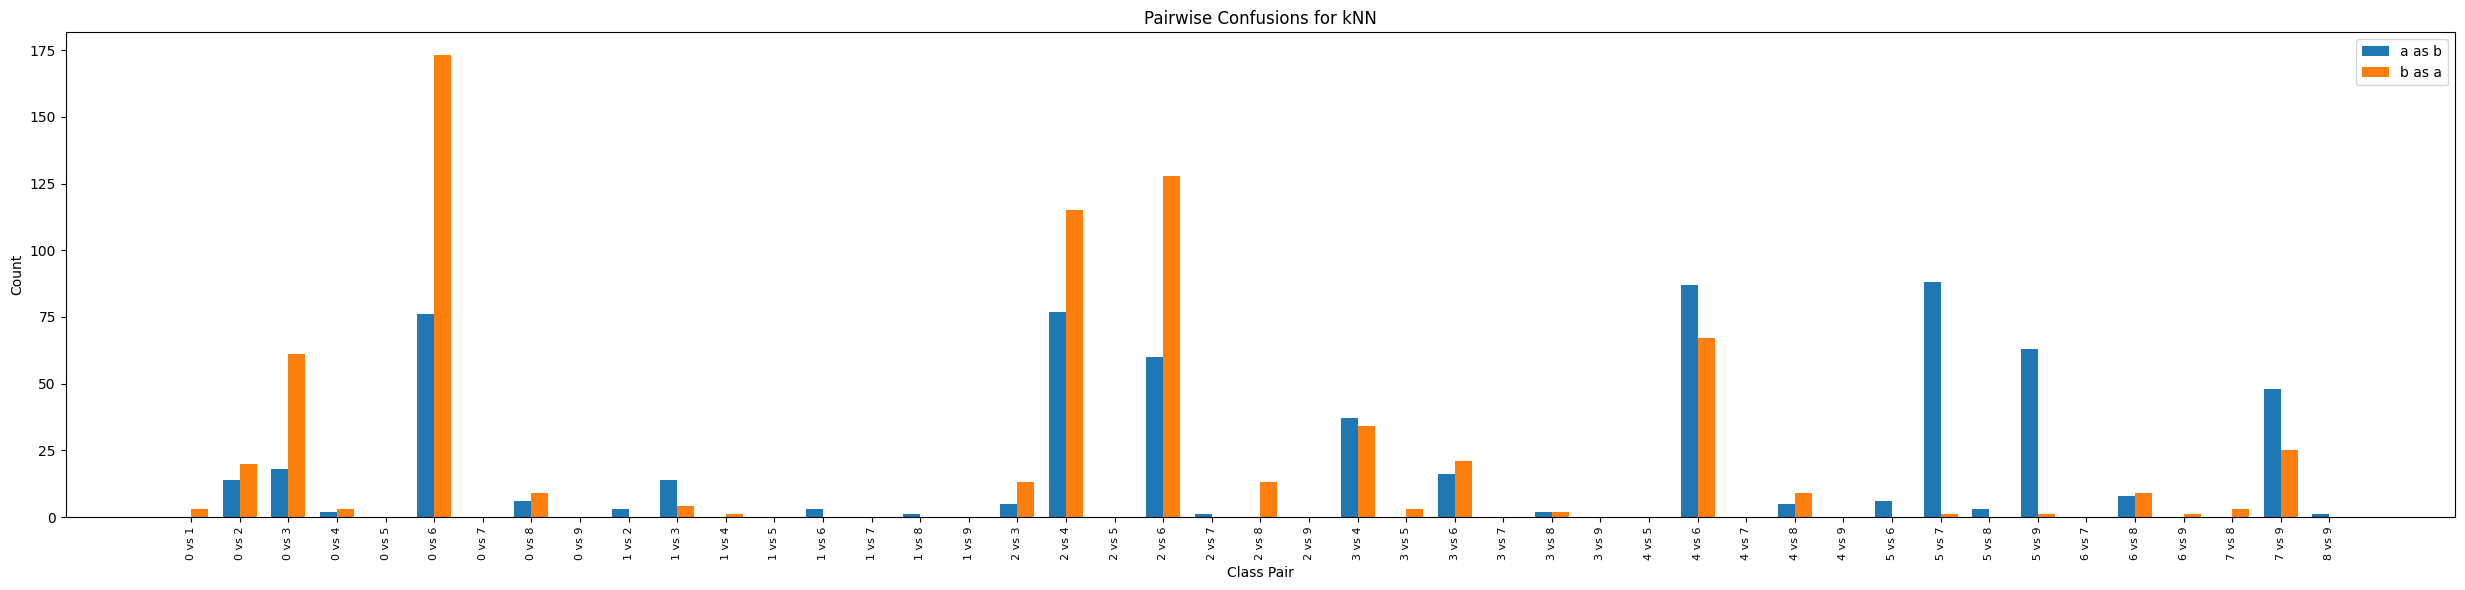

kNN class 0 AUC: 0.9604295683568913
kNN class 1 AUC: 0.9899958599044015
kNN class 2 AUC: 0.9398821383382856
kNN class 3 AUC: 0.9637601138415024
kNN class 4 AUC: 0.9297591441907935
kNN class 5 AUC: 0.960348653548224
kNN class 6 AUC: 0.865319655258974
kNN class 7 AUC: 0.9873783014555162
kNN class 8 AUC: 0.9812588085544928
kNN class 9 AUC: 0.9907071858281308


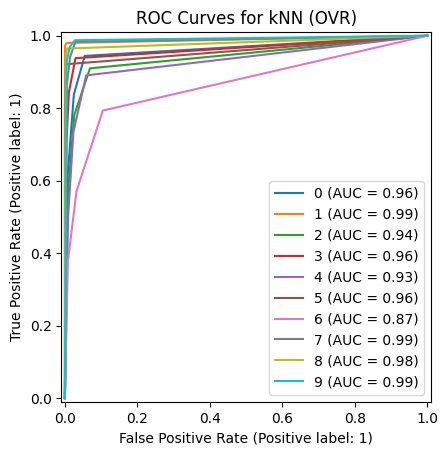

kNN pair 0 vs 5 AUC: 0.9606986899563319
kNN pair 0 vs 7 AUC: 0.991566265060241
kNN pair 0 vs 9 AUC: 0.9938132733408325


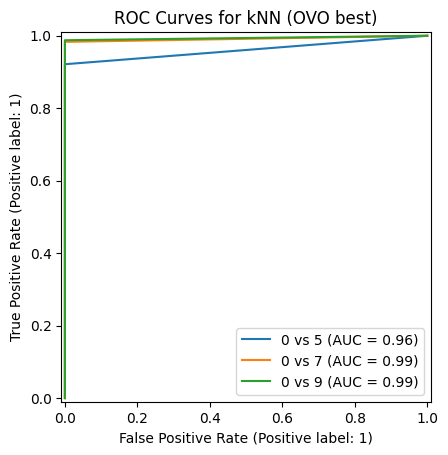

kNN pair 0 vs 6 AUC: 0.8114523644890719
kNN pair 2 vs 4 AUC: 0.8864555256064691
kNN pair 2 vs 6 AUC: 0.8267054623991361
kNN pair 4 vs 6 AUC: 0.8169322569322569
kNN pair 5 vs 7 AUC: 0.9653732835271216


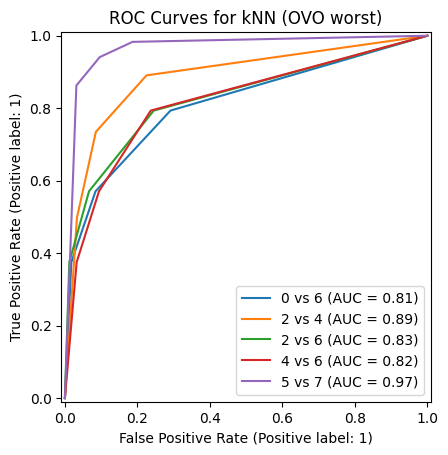

Validation time for kNN: 27.72 seconds


In [15]:
ke, kevals, k_eval_time = evaluate_model(k, "kNN", X_val, y_val, stage="validation", color="magma")
print(f"Validation time for kNN: {k_eval_time:.2f} seconds")

MLP Accuracy: 0.8466666666666667  Precision: 0.8486317903415196  Recall: 0.8466666666666667  F1 Score: 0.845625088986641


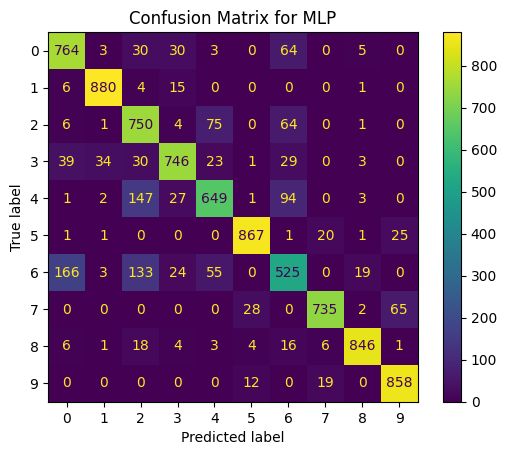

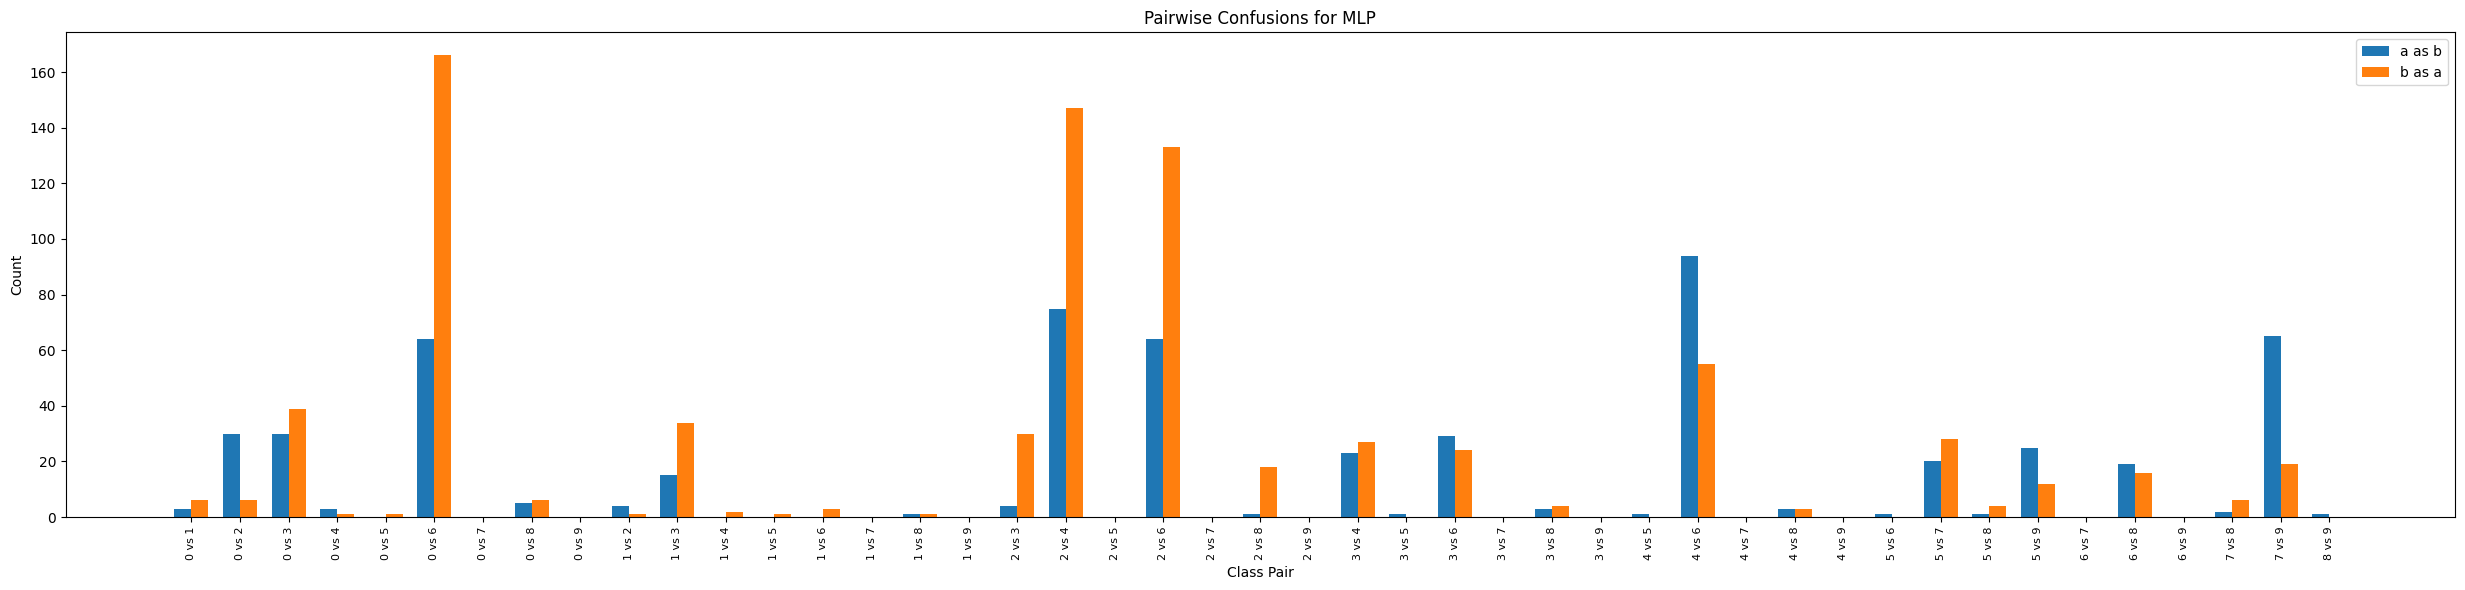

MLP class 0 AUC: 0.9837786268713443
MLP class 1 AUC: 0.9969982943242508
MLP class 2 AUC: 0.9750353526058424
MLP class 3 AUC: 0.9873773798026882
MLP class 4 AUC: 0.9778559314220533
MLP class 5 AUC: 0.9971256366017083
MLP class 6 AUC: 0.9456187432014059
MLP class 7 AUC: 0.9958630605653951
MLP class 8 AUC: 0.989168540706186
MLP class 9 AUC: 0.9964487394321672


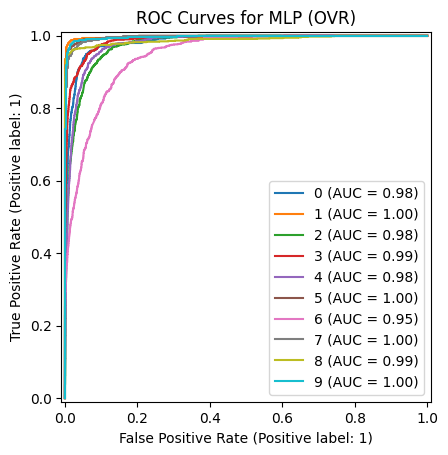

MLP pair 0 vs 7 AUC: 0.9987898200142058
MLP pair 0 vs 9 AUC: 0.9989189337984588
MLP pair 1 vs 7 AUC: 0.9999946807095933


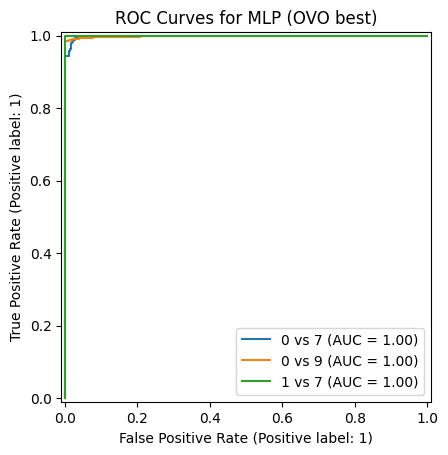

MLP pair 0 vs 6 AUC: 0.8757237771698284
MLP pair 2 vs 4 AUC: 0.9094116205658938
MLP pair 2 vs 6 AUC: 0.8505276419593844
MLP pair 4 vs 6 AUC: 0.8757189657189658
MLP pair 7 vs 9 AUC: 0.9816539498827705


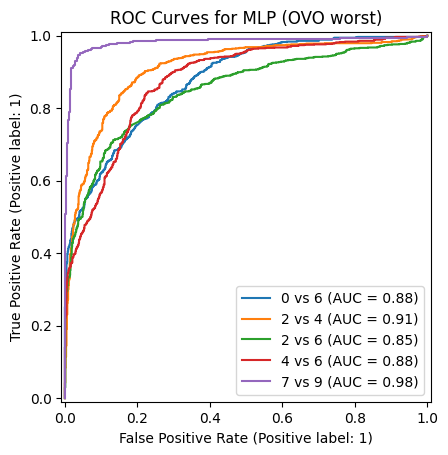

Validation time for MLP: 2.94 seconds


In [16]:
fe, fevals, fetime = evaluate_model(f, "MLP", X_val, y_val, stage="validation", color="viridis")
print(f"Validation time for MLP: {fetime:.2f} seconds")

In [19]:
ce, cevals, ctime = evaluate_model(c, "CNN", X_val_cnn, y_val, stage="validation", color="Blues")
print(f"Validation time for CNN: {ctime:.2f} seconds")

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


AttributeError: 'Sequential' object has no attribute 'predict_proba'

# Final Testing and Evaluations

In [ ]:
le_test, le_test_vals, le_test_time = evaluate_model(l, "Logistic Regression", X_test, y_test, stage="test", color="YlGnBu")
print(f"Test time for Logistic Regression: {le_test_time:.2f} seconds")

In [ ]:
ke_test, ke_test_vals, ke_test_time = evaluate_model(k, "kNN", X_test, y_test, stage="test", color="magma")
print(f"Test time for kNN: {ke_test_time:.2f} seconds")

In [ ]:
fe_test, fe_test_vals, fe_test_time = evaluate_model(f, "MLP", X_test, y_test, stage="test", color="viridis")
print(f"Test time for MLP: {fe_test_time:.2f} seconds")

In [ ]:
ce_test, ce_test_vals, ce_test_time = evaluate_model(c, "CNN", X_test_cnn, y_test, stage="test", color="Blues")
print(f"Test time for CNN: {ce_test_time:.2f} seconds")

# Comparing All Models

In [ ]:
models = ["Logistic Regression", "kNN", "MLP", "CNN"]
catcounts = {"Logistic Regression": np.diag(levals.cm) , "kNN": np.diag(kevals.cm) , "MLP": np.diag(fevals.cm), "CNN": np.diag(cevals.cm)}
cataccs = {model: counts/(len(y_test)/len(clothing_types)) for model, counts in catcounts.items()}

# Graph the numeric accuracies
x = np.arange(len(clothing_types))
width = 0.275
[plt.bar(x - width + i*width, catcounts[model], width, label=model) for i, model in enumerate(models)]
plt.xlabel('Clothing Category')
plt.ylabel('Number of Correct Predictions')
plt.title('Accuracy of Models by Clothing Category')
plt.xticks(x, [clothing_types[i] for i in clothing_types.keys()], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('figures/model_category_accuracies.png')
plt.show()

NameError: name 'np' is not defined

In [ ]:
[print(f"{model} Category Accuracy: {cataccs[model]}") for model in models]
totaccs = {model: np.round(np.mean(cataccs[model]), 4) for model in models}
print("Sorted by Overall Accuracy:", sorted([{"Logistic Regression": totaccs["Logistic Regression"]}, {"kNN": totaccs["kNN"]}, {"MLP": totaccs["MLP"]}], key=lambda x: list(x.values())[0], reverse=True))

Logistic Regression Category Accuracy: [0.08144444 0.09677778 0.07277778 0.08588889 0.08088889 0.09188889
 0.058      0.08444444 0.09155556 0.09222222]
kNN Category Accuracy: [0.087      0.098      0.082      0.08577778 0.07544444 0.08366667
 0.05866667 0.08677778 0.09544444 0.09577778]
MLP Category Accuracy: [0.082      0.09722222 0.07522222 0.087      0.08577778 0.09777778
 0.06255556 0.08466667 0.09377778 0.09311111]
Sorted by Overall Accuracy: [{'MLP': np.float64(0.0859)}, {'kNN': np.float64(0.0849)}, {'Logistic Regression': np.float64(0.0836)}]


In [ ]:
performance_by_category = pd.DataFrame({model: cataccs[model] for model in models}, index=[clothing_types[i] for i in clothing_types.keys()])
print("Performance by Category:", performance_by_category, sep="\n")
print("\nSorted by Category Accuracy:")
for category in performance_by_category.index:
    sorted_models = performance_by_category.loc[category].sort_values(ascending=False)
    print(f"Category {category}: {sorted_models.to_dict()}")

Performance by Category:
             Logistic Regression       kNN       MLP
T-shirt/top             0.081444  0.087000  0.082000
Trouser                 0.096778  0.098000  0.097222
Pullover                0.072778  0.082000  0.075222
Dress                   0.085889  0.085778  0.087000
Coat                    0.080889  0.075444  0.085778
Sandal                  0.091889  0.083667  0.097778
Shirt                   0.058000  0.058667  0.062556
Sneaker                 0.084444  0.086778  0.084667
Bag                     0.091556  0.095444  0.093778
Ankle boot              0.092222  0.095778  0.093111

Sorted by Category Accuracy:
Category T-shirt/top: {'kNN': 0.087, 'MLP': 0.082, 'Logistic Regression': 0.08144444444444444}
Category Trouser: {'kNN': 0.098, 'MLP': 0.09722222222222222, 'Logistic Regression': 0.09677777777777778}
Category Pullover: {'kNN': 0.082, 'MLP': 0.07522222222222222, 'Logistic Regression': 0.07277777777777777}
Category Dress: {'MLP': 0.087, 'Logistic Regression': 0.

In [ ]:
best_model_by_category = performance_by_category.idxmax(axis=1)
print(f"Best model by category:", best_model_by_category, sep="\n")
print(f"Model best performace counts by category: \n{best_model_by_category.value_counts()}")
print(f"Model with most category wins: {best_model_by_category.value_counts().idxmax()}")

Best model by category:
T-shirt/top    kNN
Trouser        kNN
Pullover       kNN
Dress          MLP
Coat           MLP
Sandal         MLP
Shirt          MLP
Sneaker        kNN
Bag            kNN
Ankle boot     kNN
dtype: object

Important Note: Sneakers category was actually a tie, but marked as a kNN win.
Regardless, kNN still wins 5 of 9 categories.

Model best performace counts by category: 
kNN    6
MLP    4
Name: count, dtype: int64
Model with most category wins: kNN
